# Mutual Fund Analytics - Exploratory Data Analysis (EDA)

## Objective
Analyze mutual fund datasets to identify trends in NAV, AUM, SIP inflows, investor demographics, fund performance, and portfolio allocation using Python visualizations.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

In [2]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")
nav_history = pd.read_csv("../data/raw/02_nav_history.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/raw/05_category_inflows.csv")
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")
performance = pd.read_csv("../data/raw/07_scheme_performance.csv")
transactions = pd.read_csv("../data/raw/08_investor_transactions.csv")
portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [3]:
print("Fund Master:", fund_master.shape)
print("NAV History:", nav_history.shape)
print("AUM:", aum.shape)
print("SIP:", sip.shape)
print("Category:", category.shape)
print("Folio:", folio.shape)
print("Performance:", performance.shape)
print("Transactions:", transactions.shape)
print("Portfolio:", portfolio.shape)
print("Benchmark:", benchmark.shape)

Fund Master: (40, 15)
NAV History: (46000, 3)
AUM: (90, 5)
SIP: (48, 6)
Category: (144, 3)
Folio: (21, 6)
Performance: (40, 19)
Transactions: (32778, 13)
Portfolio: (322, 8)
Benchmark: (8050, 3)


In [4]:
fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [5]:
nav_history.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


## NAV Trend Analysis
This section analyzes the daily NAV trend of mutual fund schemes from 2022–2026.

In [6]:
# Convert date column to datetime
nav_history["date"] = pd.to_datetime(nav_history["date"])

# Sort data
nav_history = nav_history.sort_values(["amfi_code", "date"])

# Display first rows
nav_history.head()

,amfi_code,date,nav
5750,100016,2022-01-03,520.4608
5751,100016,2022-01-04,515.0971
5752,100016,2022-01-05,521.7239
5753,100016,2022-01-06,515.7880
5754,100016,2022-01-07,515.1639


In [7]:
import plotly.express as px

fig = px.line(
    nav_history,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (2022–2026)"
)

fig.show()

### Observation
The chart shows the variation in daily NAV across mutual fund schemes over time. This visualization helps identify overall market trends and compare scheme performance.

## AUM Growth Analysis
This chart compares the Assets Under Management (AUM) of fund houses across different years.

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_cr",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022-2025)")
plt.xlabel("Year")
plt.ylabel("AUM (₹ Crores)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

ValueError: Could not interpret value `year` for `x`. An entry with this name does not appear in `data`.

<Figure size 1200x600 with 0 Axes>

In [10]:
print(aum.columns)

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')


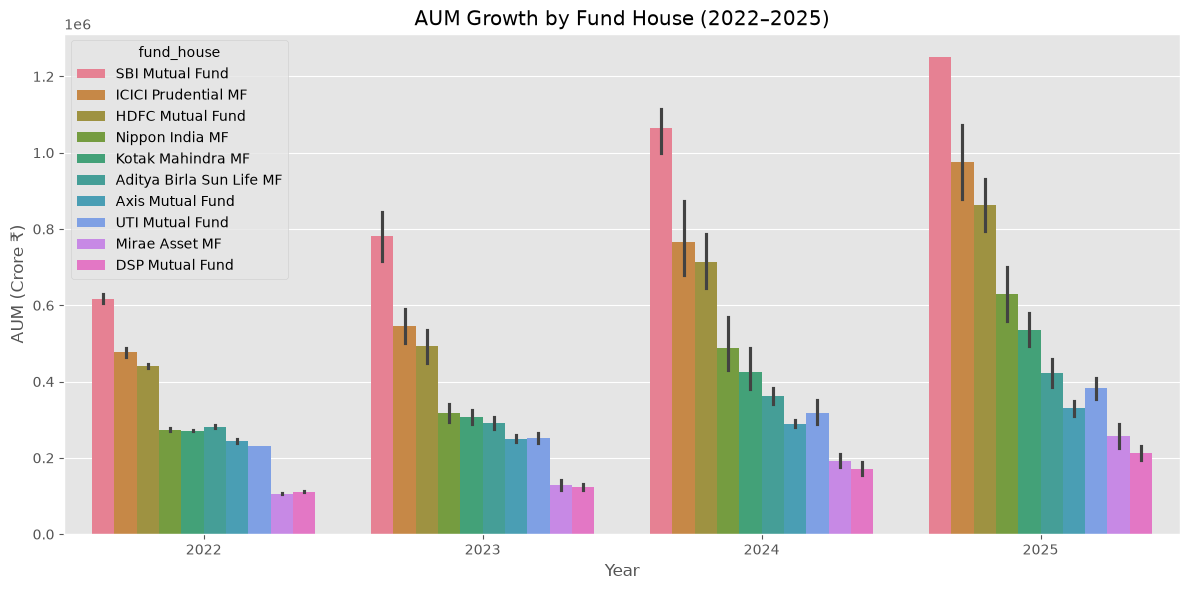

In [11]:
# Convert date column to datetime
aum['date'] = pd.to_datetime(aum['date'])

# Create year column
aum['year'] = aum['date'].dt.year

# Plot AUM growth
plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Crore ₹)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Observation
The AUM chart compares the growth of different fund houses from 2022 to 2025. SBI Mutual Fund shows the highest AUM, indicating its market leadership.

## SIP Inflow Time-Series
This section visualizes the monthly SIP inflow trend from January 2022 to December 2025.

In [12]:
print(sip.columns)

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')


In [13]:
# Convert month to datetime
sip['month'] = pd.to_datetime(sip['month'])

sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,NaN
1,2022-02-01,11438,4.93,8.20,4.85,NaN
2,2022-03-01,12328,5.09,10.50,5.01,NaN
3,2022-04-01,11863,5.48,9.52,5.12,NaN
4,2022-05-01,12286,5.55,8.10,5.15,NaN


In [14]:
import plotly.express as px

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend (Jan 2022 - Dec 2025)",
    markers=True
)

# Highlight highest SIP inflow
max_idx = sip["sip_inflow_crore"].idxmax()

fig.add_annotation(
    x=sip.loc[max_idx, "month"],
    y=sip.loc[max_idx, "sip_inflow_crore"],
    text="Highest SIP Inflow",
    showarrow=True,
    arrowhead=2
)

fig.show()

### Observation

The monthly SIP inflow shows a steady upward trend from 2022 to 2025. The highest SIP inflow is highlighted in the chart, indicating strong growth in retail mutual fund investments.

In [15]:
print(category.columns)

Index(['month', 'category', 'net_inflow_crore'], dtype='str')


In [16]:
category["month"] = pd.to_datetime(category["month"])
category.head()

,month,category,net_inflow_crore
0,2024-04-01,Large Cap,2413.0
1,2024-04-01,Mid Cap,3897.0
2,2024-04-01,Small Cap,3533.0
3,2024-04-01,Flexi Cap,4947.0
4,2024-04-01,Large & Mid Cap,4214.0


In [17]:
heatmap_data = category.pivot_table(
    values="net_inflow_crore",
    index="category",
    columns="month"
)

heatmap_data

month,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0
Large Cap,2413.0,2076.0,2519.0,2574.0,1940.0,1879.0,2255.0,1870.0,1923.0,2025.0,1925.0,2234.0
Liquid,37537.0,41872.0,40486.0,34643.0,41952.0,35308.0,39091.0,40506.0,34933.0,33892.0,32374.0,38681.0
Mid Cap,3897.0,5300.0,5047.0,4548.0,3899.0,4960.0,4106.0,4336.0,5023.0,4316.0,4819.0,5061.0
Sectoral/Thematic,8052.0,8354.0,10030.0,9896.0,8360.0,8518.0,7680.0,7397.0,9820.0,7893.0,9215.0,8614.0


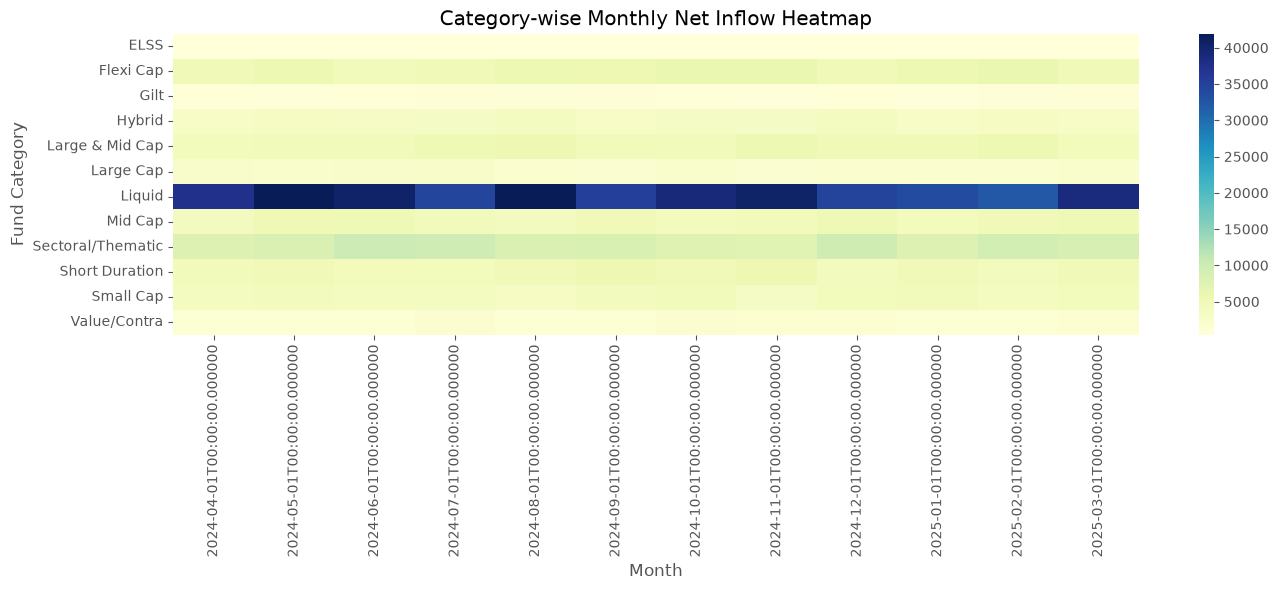

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=False
)

plt.title("Category-wise Monthly Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()
plt.show()

### Observation

The heatmap highlights monthly net inflows across different mutual fund categories. Darker shades indicate higher inflows, making it easy to identify periods of strong investor interest in specific fund categories.

In [19]:
print(transactions.columns)

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')


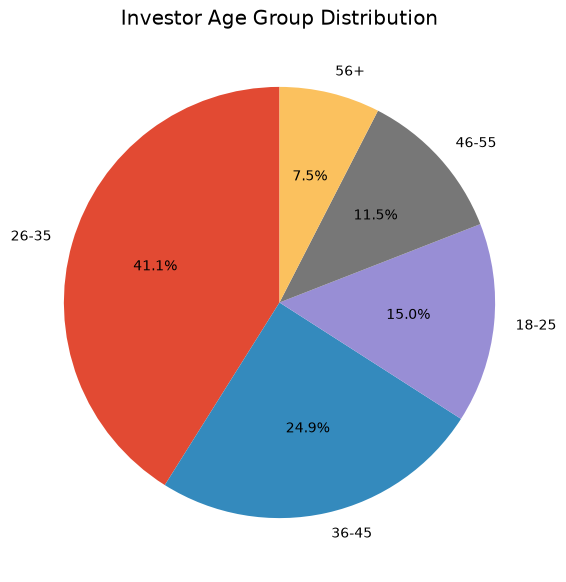

In [20]:
import matplotlib.pyplot as plt

age_counts = transactions["age_group"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")
plt.show()

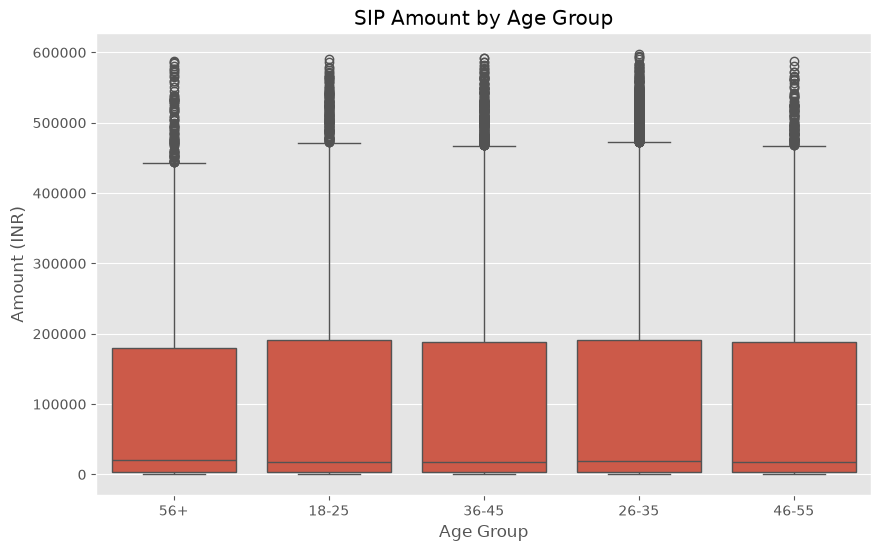

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Amount (INR)")

plt.show()

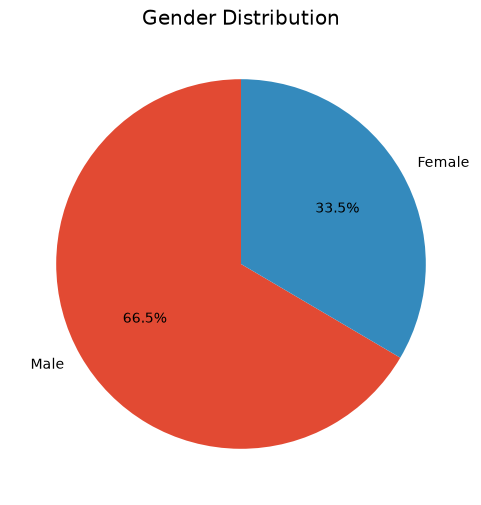

In [22]:
gender_counts = transactions["gender"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution")

plt.show()

### Observation

- Most investors belong to a specific age group, indicating the primary investment demographic.
- SIP investment amounts vary across age groups, with some groups showing greater variability.
- The gender distribution chart illustrates the proportion of male and female investors in the dataset.

In [23]:
transactions[['state', 'city_tier', 'amount_inr']].head()

,state,city_tier,amount_inr
0,Telangana,T30,1834
1,Punjab,B30,392882
2,Haryana,B30,912
3,Maharashtra,T30,1102
4,Delhi,T30,8682


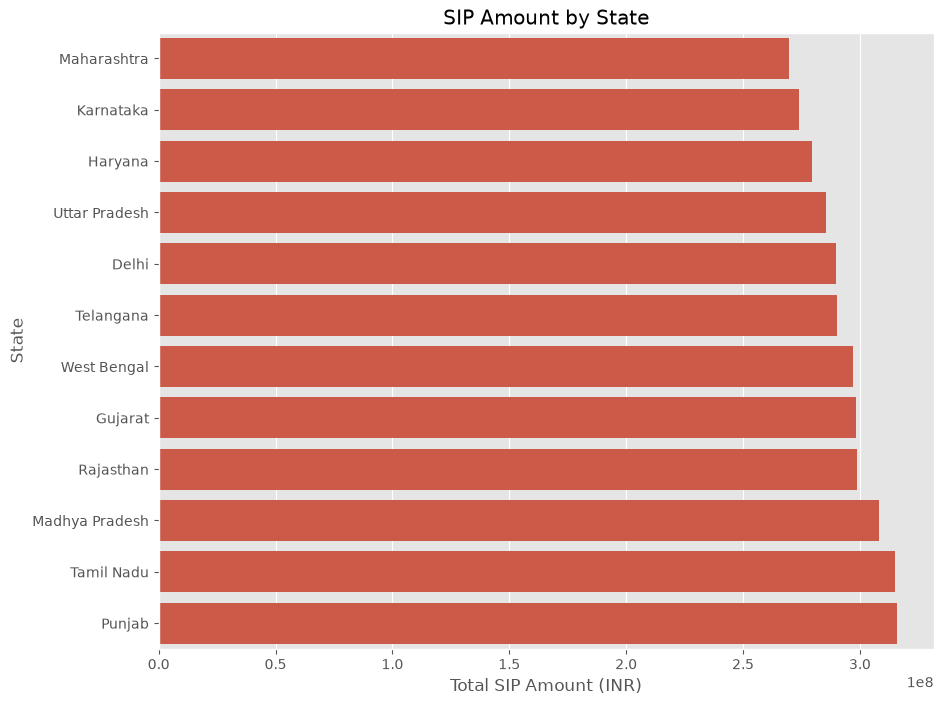

In [24]:
state_sip = transactions.groupby("state")["amount_inr"].sum().sort_values()

plt.figure(figsize=(10,8))

sns.barplot(
    x=state_sip.values,
    y=state_sip.index
)

plt.title("SIP Amount by State")
plt.xlabel("Total SIP Amount (INR)")
plt.ylabel("State")

plt.show()

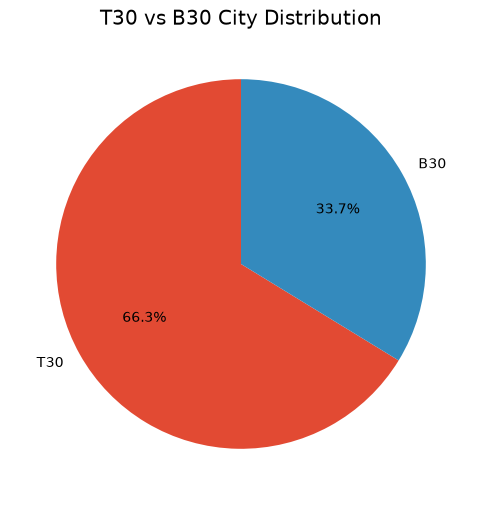

In [25]:
city_counts = transactions["city_tier"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    city_counts,
    labels=city_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("T30 vs B30 City Distribution")

plt.show()

### Observation

The state-wise chart shows which states contribute the highest SIP investment amounts. The city tier chart compares investor participation between T30 and B30 cities.

In [27]:
print(folio.columns)

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')


In [28]:
folio["month"] = pd.to_datetime(folio["month"])

In [29]:
import plotly.express as px

fig = px.line(
    folio,
    x="month",
    y="total_folios_crore",
    title="Growth in Total Mutual Fund Folios (2022–2025)",
    markers=True
)

# Highlight first and last values
fig.add_annotation(
    x=folio.iloc[0]["month"],
    y=folio.iloc[0]["total_folios_crore"],
    text="Jan 2022",
    showarrow=True
)

fig.add_annotation(
    x=folio.iloc[-1]["month"],
    y=folio.iloc[-1]["total_folios_crore"],
    text="Dec 2025",
    showarrow=True
)

fig.show()

### Observation

The total number of mutual fund folios shows a steady upward trend from 2022 to 2025, indicating increasing investor participation throughout the period.

In [30]:
print(nav_history.columns)

Index(['amfi_code', 'date', 'nav'], dtype='str')


In [31]:
# Ensure data is sorted
nav_history = nav_history.sort_values(["amfi_code", "date"])

# Calculate daily return
nav_history["daily_return"] = (
    nav_history.groupby("amfi_code")["nav"].pct_change()
)

nav_history.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [32]:
# Select first 10 funds
selected_funds = nav_history["amfi_code"].unique()[:10]

corr_data = nav_history[
    nav_history["amfi_code"].isin(selected_funds)
]

pivot_df = corr_data.pivot(
    index="date",
    columns="amfi_code",
    values="daily_return"
)

pivot_df.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
date,,,,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,-0.010306,-0.003553,-0.013328,0.001153,-0.010865,-0.000141,0.011122,0.011314,-0.010459,-0.000714
2022-01-05,0.012865,-0.000050,-0.004386,0.003866,0.000603,0.000382,-0.007878,0.006779,-0.005308,0.005913
2022-01-06,-0.011377,-0.001880,-0.005167,-0.002128,-0.029101,-0.000143,0.015277,0.031127,0.012678,0.003540
2022-01-07,-0.001210,0.002036,-0.005748,-0.006314,0.024766,0.000215,-0.009369,-0.008835,-0.016498,-0.005793


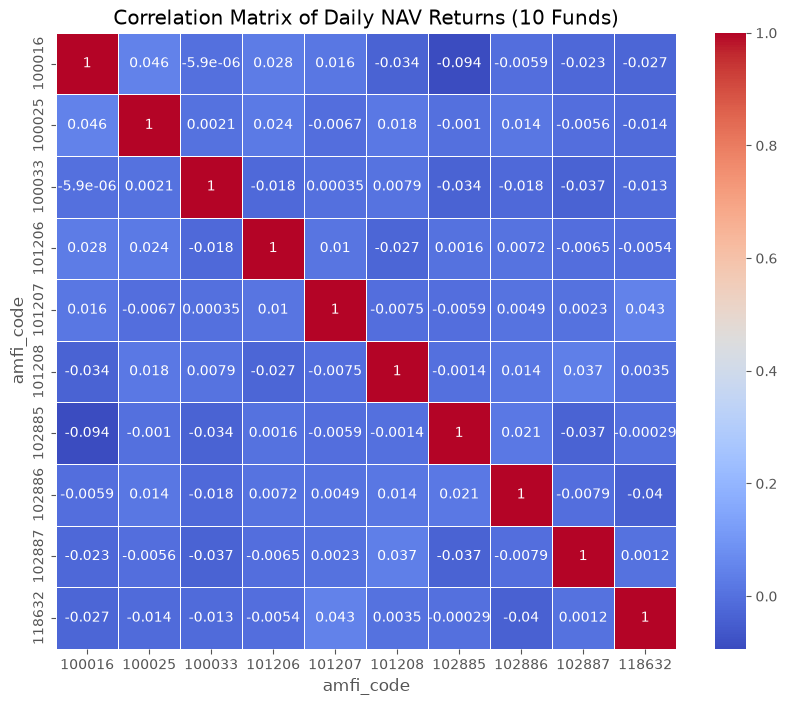

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    pivot_df.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix of Daily NAV Returns (10 Funds)")
plt.show()

### Observation

The correlation matrix shows how closely the daily returns of selected mutual funds move together. Higher positive correlation indicates similar performance patterns, while lower correlation suggests diversification opportunities.

In [34]:
print(portfolio.columns)

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


In [35]:
sector_data = portfolio.groupby("sector")["weight_pct"].sum().reset_index()

sector_data.head()

,sector,weight_pct
0,Automobile,323.65
1,Banking,652.26
2,Cement,105.03
3,Consumer Goods,127.61
4,Diversified,169.23


In [36]:
import plotly.express as px

fig = px.pie(
    sector_data,
    names="sector",
    values="weight_pct",
    hole=0.5,
    title="Sector Allocation Across Equity Funds"
)

fig.show()

### Observation

The donut chart shows the overall sector allocation across equity mutual funds. Sectors with larger weights represent the dominant investment allocation in the portfolio.

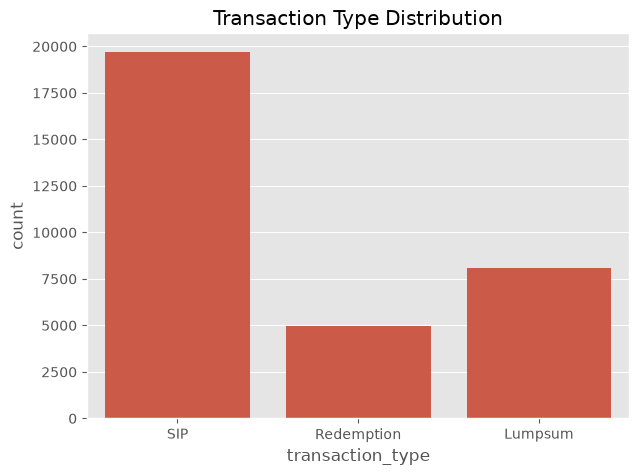

In [37]:
plt.figure(figsize=(7,5))

sns.countplot(data=transactions, x="transaction_type")

plt.title("Transaction Type Distribution")
plt.show()

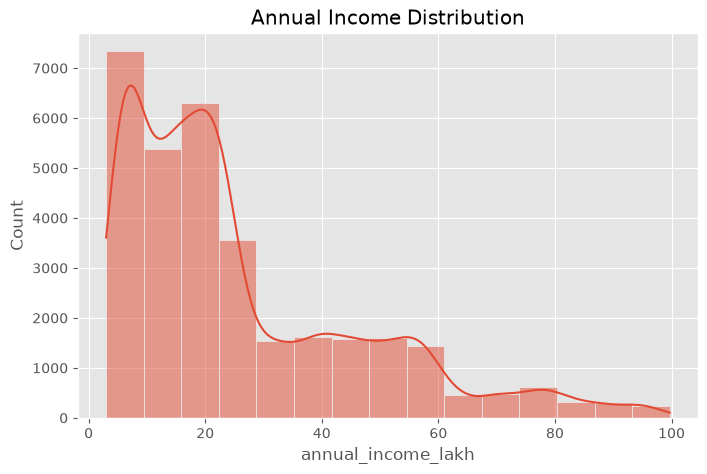

In [38]:
plt.figure(figsize=(8,5))

sns.histplot(
    transactions["annual_income_lakh"],
    bins=15,
    kde=True
)

plt.title("Annual Income Distribution")
plt.show()

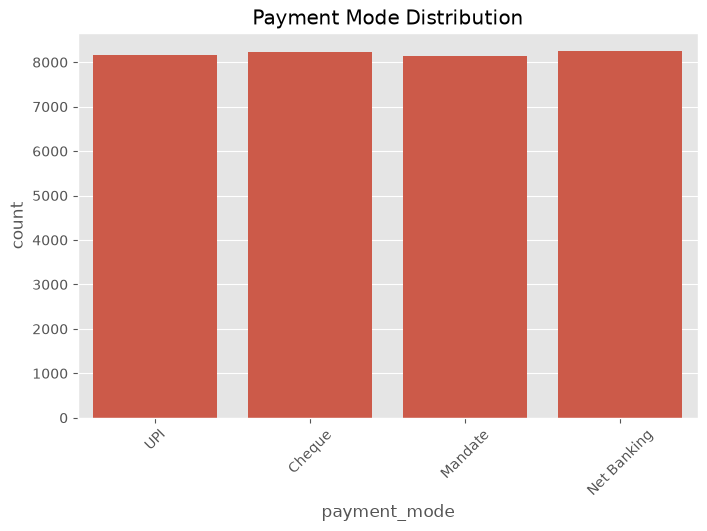

In [39]:
plt.figure(figsize=(8,5))

sns.countplot(data=transactions, x="payment_mode")

plt.title("Payment Mode Distribution")
plt.xticks(rotation=45)
plt.show()